# Climate-Informed Country Embedding for Migration Estimation

This notebook generates contextually informed embeddings for country ISO3 codes based on climate migration features from World Bank indicators rather than random initialization.

In [13]:
import requests
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
WORLD_BANK_API = "https://api.worldbank.org/v2/country/all/indicator"
INDICATORS = {
    "gdp_pc": "NY.GDP.PCAP.PP.KD",
    "agri_gdp": "NV.AGR.TOTL.ZS",
    "rural_pop": "SP.RUR.TOTL.ZS",
    "pop_density": "EN.POP.DNST",
    "electricity": "EG.ELC.ACCS.ZS",
    "school_enroll": "SE.SEC.ENRR",
}
YEAR_RANGE = (2015, 2023)

# Region mapping for visualization (comprehensive and non-overlapping)
REGION_MAP = {
    # Africa
    'AGO': 'Africa', 'BWA': 'Africa', 'CMR': 'Africa', 'COD': 'Africa', 'COG': 'Africa',
    'CIV': 'Africa', 'DZA': 'Africa', 'EGY': 'Africa', 'ETH': 'Africa', 'GAB': 'Africa', 
    'GHA': 'Africa', 'GIN': 'Africa', 'GMB': 'Africa', 'KEN': 'Africa', 'LBR': 'Africa',
    'MAR': 'Africa', 'MLI': 'Africa', 'MOZ': 'Africa', 'MWI': 'Africa', 'NAM': 'Africa',
    'NGA': 'Africa', 'RWA': 'Africa', 'SEN': 'Africa', 'SOM': 'Africa', 'ZAF': 'Africa',
    'TZA': 'Africa', 'TGO': 'Africa', 'TUN': 'Africa', 'UGA': 'Africa', 'ZMB': 'Africa', 'ZWE': 'Africa',
    # Americas
    'ARG': 'Americas', 'BOL': 'Americas', 'BRA': 'Americas', 'CAN': 'Americas', 'CHL': 'Americas',
    'COL': 'Americas', 'CRI': 'Americas', 'CUB': 'Americas', 'DOM': 'Americas', 'ECU': 'Americas',
    'SLV': 'Americas', 'GTM': 'Americas', 'GUY': 'Americas', 'HTI': 'Americas', 'HND': 'Americas',
    'JAM': 'Americas', 'MEX': 'Americas', 'NIC': 'Americas', 'PAN': 'Americas', 'PRY': 'Americas',
    'PER': 'Americas', 'URY': 'Americas', 'VEN': 'Americas', 'USA': 'Americas', 'BRB': 'Americas',
    # Asia
    'AFG': 'Asia', 'BGD': 'Asia', 'BTN': 'Asia', 'KHM': 'Asia', 'CHN': 'Asia', 'IND': 'Asia',
    'IDN': 'Asia', 'JPN': 'Asia', 'KAZ': 'Asia', 'KOR': 'Asia', 'KGZ': 'Asia',
    'LAO': 'Asia', 'MYS': 'Asia', 'MDV': 'Asia', 'MNG': 'Asia', 'MMR': 'Asia',
    'NPL': 'Asia', 'PAK': 'Asia', 'PHL': 'Asia', 'SGP': 'Asia', 'LKA': 'Asia',
    'THA': 'Asia', 'TLS': 'Asia', 'TJK': 'Asia', 'TKM': 'Asia', 'UZB': 'Asia', 'VNM': 'Asia',
    'HKG': 'Asia', 'MAC': 'Asia', 'TWN': 'Asia',
    # Europe
    'ALB': 'Europe', 'AND': 'Europe', 'AUT': 'Europe', 'BLR': 'Europe', 'BEL': 'Europe',
    'BIH': 'Europe', 'BGR': 'Europe', 'HRV': 'Europe', 'CYP': 'Europe', 'CZE': 'Europe',
    'DNK': 'Europe', 'EST': 'Europe', 'FIN': 'Europe', 'FRA': 'Europe', 'DEU': 'Europe',
    'GRC': 'Europe', 'HUN': 'Europe', 'ISL': 'Europe', 'IRL': 'Europe', 'ITA': 'Europe',
    'XKX': 'Europe', 'LVA': 'Europe', 'LIE': 'Europe', 'LTU': 'Europe', 'LUX': 'Europe',
    'MKD': 'Europe', 'MLT': 'Europe', 'MDA': 'Europe', 'MCO': 'Europe', 'MNE': 'Europe',
    'NLD': 'Europe', 'NOR': 'Europe', 'POL': 'Europe', 'PRT': 'Europe', 'ROU': 'Europe',
    'RUS': 'Europe', 'SMR': 'Europe', 'SRB': 'Europe', 'SVK': 'Europe', 'SVN': 'Europe',
    'ESP': 'Europe', 'SWE': 'Europe', 'CHE': 'Europe', 'UKR': 'Europe', 'GBR': 'Europe',
    # Middle East & North Africa  
    'BHR': 'MENA', 'IRN': 'MENA', 'IRQ': 'MENA',
    'ISR': 'MENA', 'JOR': 'MENA', 'KWT': 'MENA', 'LBN': 'MENA', 'LBY': 'MENA',
    'OMN': 'MENA', 'QAT': 'MENA', 'SAU': 'MENA', 'SYR': 'MENA',
    'TUR': 'MENA', 'ARE': 'MENA', 'YEM': 'MENA',
    # Oceania
    'AUS': 'Oceania', 'FJI': 'Oceania', 'KIR': 'Oceania', 'MHL': 'Oceania',
    'FSM': 'Oceania', 'NRU': 'Oceania', 'NZL': 'Oceania', 'PLW': 'Oceania',
    'PNG': 'Oceania', 'WSM': 'Oceania', 'SLB': 'Oceania', 'TON': 'Oceania', 'TUV': 'Oceania', 'VUT': 'Oceania',
}


def fetch_world_bank_indicator(indicator_code):
    """Fetch World Bank indicator data for all countries and years."""
    response = requests.get(f"{WORLD_BANK_API}/{indicator_code}", 
                           params={"format": "json", "per_page": 20000})
    data = response.json()[1]
    
    records = [(d["country"]["id"], int(d["date"]), d["value"]) 
               for d in data if d["value"] is not None]
    
    return pd.DataFrame(records, columns=["country", "year", indicator_code])


def build_climate_dataset(indicators=INDICATORS, year_range=YEAR_RANGE):
    """Build climate indicator dataset by aggregating World Bank data."""
    years = list(range(year_range[0], year_range[1]))
    dfs = []
    
    for name, code in indicators.items():
        df = fetch_world_bank_indicator(code)
        df = df[df["year"].isin(years)].groupby("country")[code].mean().rename(name)
        dfs.append(df)
    
    return pd.concat(dfs, axis=1)


def compute_embeddings(data, n_components=6):
    """Compute PCA embeddings from climate indicators."""
    # Impute missing values with median
    X = SimpleImputer(strategy="median").fit_transform(data)
    # Standardize features
    X = StandardScaler().fit_transform(X)
    # Compute PCA embeddings
    embeddings = PCA(n_components=n_components).fit_transform(X)
    
    return pd.DataFrame(embeddings, index=data.index,
                       columns=[f"emb_{i}" for i in range(n_components)])


def add_region_labels(embeddings, region_map=REGION_MAP):
    """Add region labels to embeddings for visualization."""
    embeddings["region"] = embeddings.index.map(
        lambda x: region_map.get(x, "Other")
    )
    return embeddings

In [14]:
def plot_embeddings(embeddings, hue=None, title="Country Embeddings", figsize=(14, 10)):
    """Visualize 2D embeddings as a scatter plot with improved styling."""
    # Use seaborn style for better aesthetics
    with sns.plotting_context("talk", font_scale=1.1):
        fig, ax = plt.subplots(figsize=figsize, dpi=100)
        
        # Create scatter plot with region colors
        if hue is not None:
            palette = sns.color_palette("husl", len(embeddings[hue].unique()))
        else:
            palette = "Set2"
            
        sns.scatterplot(
            x="emb_0", y="emb_1", 
            data=embeddings, 
            hue=hue, 
            palette=palette,
            s=200, 
            alpha=0.75, 
            edgecolor="white",
            linewidth=1.5,
            ax=ax
        )
        
        # Label outlier countries (extreme points)
        # Find points that are far from center
        center = embeddings[["emb_0", "emb_1"]].mean()
        distances = ((embeddings[["emb_0", "emb_1"]] - center) ** 2).sum(axis=1) ** 0.5
        top_outliers = distances.nlargest(8).index
        
        for country in top_outliers:
            x, y = embeddings.loc[country, "emb_0"], embeddings.loc[country, "emb_1"]
            ax.annotate(country, xy=(x, y), xytext=(5, 5), textcoords="offset points",
                       fontsize=9, alpha=0.7, bbox=dict(boxstyle="round,pad=0.3", 
                       facecolor="yellow", alpha=0.1, edgecolor="none"))
        
        # Add subtle grid for reference
        ax.grid(True, alpha=0.2, linestyle="--", linewidth=0.5)
        
        # Styling
        ax.set_title(title, fontsize=16, fontweight="bold", pad=20)
        ax.set_xlabel("Embedding Dimension 1", fontsize=13)
        ax.set_ylabel("Embedding Dimension 2", fontsize=13)
        
        # Improve legend
        if hue is not None:
            ax.legend(
                title="Region",
                title_fontsize=12,
                fontsize=11,
                framealpha=0.95,
                loc="best",
                bbox_to_anchor=(1.02, 1),
                borderpad=1
            )
        
        # Add subtle spines
        sns.despine(left=False, bottom=False, ax=ax)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        
        plt.tight_layout()
        plt.show()


Building climate dataset...
  Loaded 265 countries × 6 indicators
Computing 2D embeddings...
Generating visualization...


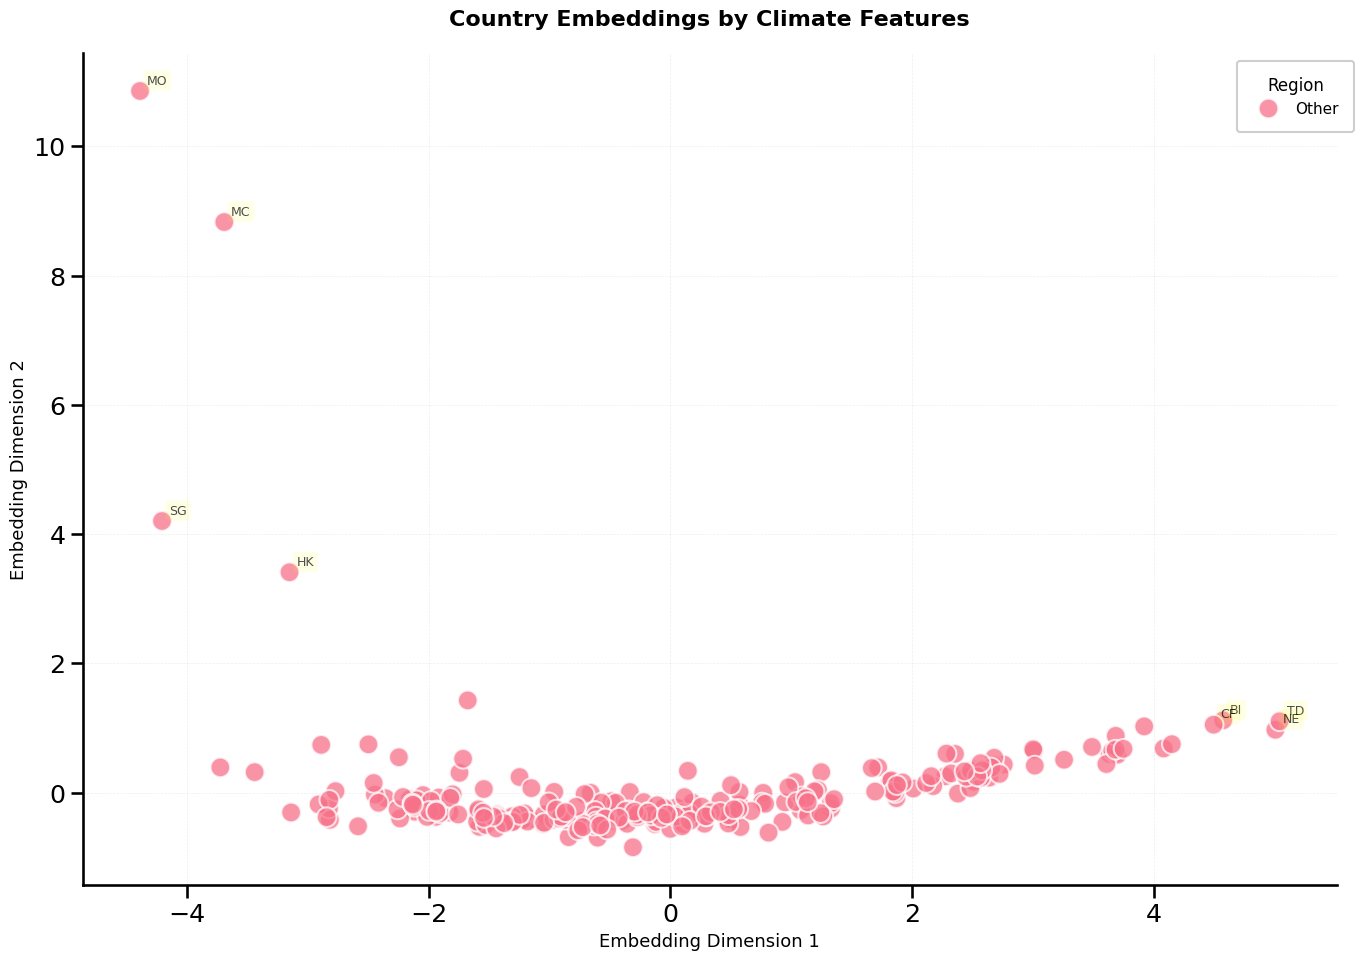

In [15]:
# Build and visualize embeddings
print("Building climate dataset...")
climate_data = build_climate_dataset()
print(f"  Loaded {climate_data.shape[0]} countries × {climate_data.shape[1]} indicators")

print("Computing 2D embeddings...")
embeddings = compute_embeddings(climate_data, n_components=2)
embeddings = add_region_labels(embeddings)

print("Generating visualization...")
plot_embeddings(embeddings, hue="region", title="Country Embeddings by Climate Features")

## Analysis: Determining Optimal Number of Components

To find the best number of PCA components, we analyze **explained variance ratio** — how much information each component preserves from the original data. We'll examine:
- **Individual variance**: How much each component contributes
- **Cumulative variance**: Total information captured by N components
- **Scree plot**: Visual representation to find the "elbow" point

In [16]:
# Analyze explained variance for different numbers of components
print("Building climate dataset for variance analysis...")
climate_data = build_climate_dataset()

# Prepare data (impute + standardize, same as compute_embeddings)
X = SimpleImputer(strategy="median").fit_transform(climate_data)
X = StandardScaler().fit_transform(X)

# Fit PCA with all possible components (limited by number of features)
n_features = X.shape[1]  # 6 climate indicators
pca_full = PCA(n_components=n_features)
pca_full.fit(X)

# Get explained variance
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Print analysis
print("\n" + "="*60)
print("EXPLAINED VARIANCE ANALYSIS")
print("="*60)
print(f"\nTotal features (indicators): {n_features}")
print(f"\nVariance explained by each component:")
for i, (var, cum_var) in enumerate(zip(explained_variance, cumulative_variance), 1):
    print(f"  PC{i}: {var*100:6.2f}% (cumulative: {cum_var*100:6.2f}%)")

# Find components for common thresholds
threshold_95 = np.argmax(cumulative_variance >= 0.95) + 1
threshold_90 = np.argmax(cumulative_variance >= 0.90) + 1
threshold_80 = np.argmax(cumulative_variance >= 0.80) + 1

print(f"\n{'RECOMMENDATIONS:':^60}")
print(f"  95% variance: {threshold_95} component(s)")
print(f"  90% variance: {threshold_90} component(s)")
print(f"  80% variance: {threshold_80} component(s)")
print("="*60)

Building climate dataset for variance analysis...

EXPLAINED VARIANCE ANALYSIS

Total features (indicators): 6

Variance explained by each component:
  PC1:  57.67% (cumulative:  57.67%)
  PC2:  16.81% (cumulative:  74.47%)
  PC3:   9.54% (cumulative:  84.01%)
  PC4:   6.51% (cumulative:  90.52%)
  PC5:   4.90% (cumulative:  95.43%)
  PC6:   4.57% (cumulative: 100.00%)

                      RECOMMENDATIONS:                      
  95% variance: 5 component(s)
  90% variance: 4 component(s)
  80% variance: 3 component(s)


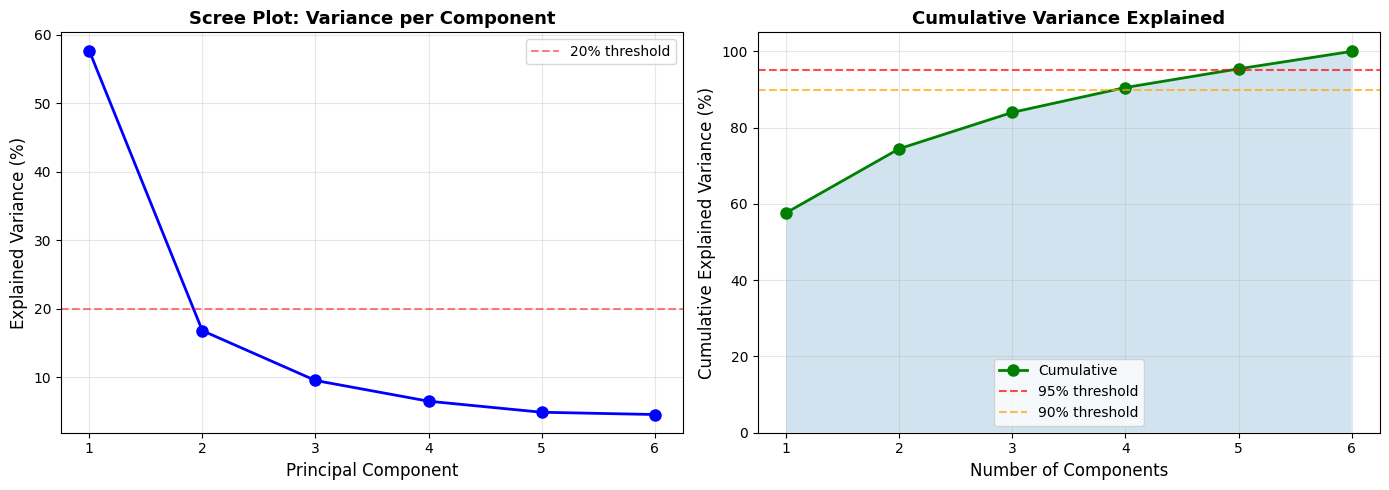

In [17]:
# Visualize explained variance with scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot (individual variance)
ax1 = axes[0]
components = np.arange(1, len(explained_variance) + 1)
ax1.plot(components, explained_variance * 100, 'bo-', linewidth=2, markersize=8)
ax1.axhline(y=20, color='r', linestyle='--', alpha=0.5, label='20% threshold')
ax1.set_xlabel("Principal Component", fontsize=12)
ax1.set_ylabel("Explained Variance (%)", fontsize=12)
ax1.set_title("Scree Plot: Variance per Component", fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(components)
ax1.legend()

# Cumulative variance plot
ax2 = axes[1]
ax2.plot(components, cumulative_variance * 100, 'go-', linewidth=2, markersize=8, label='Cumulative')
ax2.axhline(y=95, color='r', linestyle='--', alpha=0.7, label='95% threshold')
ax2.axhline(y=90, color='orange', linestyle='--', alpha=0.7, label='90% threshold')
ax2.fill_between(components, 0, cumulative_variance * 100, alpha=0.2)
ax2.set_xlabel("Number of Components", fontsize=12)
ax2.set_ylabel("Cumulative Explained Variance (%)", fontsize=12)
ax2.set_title("Cumulative Variance Explained", fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(components)
ax2.set_ylim([0, 105])
ax2.legend()

plt.tight_layout()
plt.show()

## Findings & Recommendations

**Your data (6 climate indicators):**
- **PC1** captures **57.67%** of variance — strong primary pattern in climate/economy
- **PC2** captures **16.81%** — secondary differentiator (good for 2D visualization!)  
- **PC3** captures **9.54%** — tertiary patterns

**How to choose:**

| Use case | Components | Variance | Tradeoff |
|----------|-----------|----------|----------|
| **Visualization** | 2 | 74.47% | Easy to plot, loses ~25% info |
| **Detailed analysis** | 3 | 84.01% | Good balance |
| **High fidelity** | 4 | 90.52% | Most detail without noise |
| **Maximum preservation** | 5+ | 95%+ | Diminishing returns |

**For this analysis:**
- **2 components (current)** is good for visualization because it captures the main patterns while fitting in 2D
- **3 components** would better preserve information if you plan to use embeddings for ML models
- **4+ components** adds minimal value (small incremental gains per component)

## Comparison: 2D vs 3D Embeddings

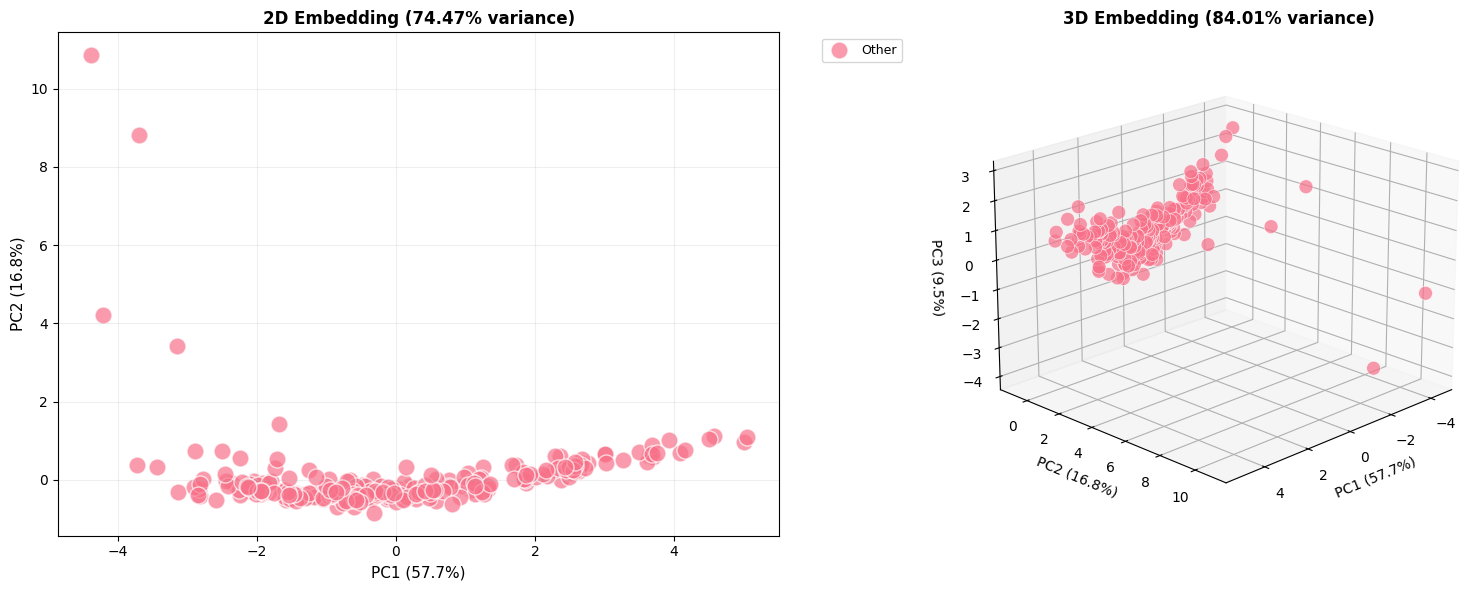

Saved embeddings to src/data/embeddings_iso3_3d.csv
         emb_0     emb_1     emb_2
iso3                              
1A    0.174424 -0.285807  0.034587
1W   -0.012361 -0.329130 -0.087382
4E   -0.148154 -0.347723 -0.459096
7E   -0.690641 -0.407795 -0.391256
8S    1.121288 -0.085484 -0.940301

2D vs 3D Comparison:
  2D: Captures 74.47% variance
  3D: Captures 84.01% variance
  Improvement: +9.54% (3rd component adds modest value)


In [20]:
from mpl_toolkits.mplot3d import Axes3D
import os

# Build embeddings with both 2D and 3D for comparison
climate_data = build_climate_dataset()
embeddings_2d = compute_embeddings(climate_data, n_components=2)
embeddings_3d = compute_embeddings(climate_data, n_components=3)

# Add region labels
embeddings_2d = add_region_labels(embeddings_2d)
embeddings_3d = add_region_labels(embeddings_3d)

# Create comparison plots
fig = plt.figure(figsize=(16, 6))

# 2D plot
ax1 = fig.add_subplot(121)
regions_2d = embeddings_2d['region'].unique()
palette = sns.color_palette("husl", len(regions_2d))
for region, color in zip(sorted(regions_2d), palette):
    mask = embeddings_2d['region'] == region
    ax1.scatter(embeddings_2d[mask]['emb_0'], embeddings_2d[mask]['emb_1'], 
               label=region, s=150, alpha=0.7, edgecolor='white', linewidth=1, color=color)

ax1.set_xlabel(f"PC1 ({explained_variance[0]*100:.1f}%)", fontsize=11)
ax1.set_ylabel(f"PC2 ({explained_variance[1]*100:.1f}%)", fontsize=11)
ax1.set_title("2D Embedding (74.47% variance)", fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.2)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

# 3D plot
ax2 = fig.add_subplot(122, projection='3d')
for region, color in zip(sorted(regions_2d), palette):
    mask = embeddings_3d['region'] == region
    ax2.scatter(embeddings_3d[mask]['emb_0'], embeddings_3d[mask]['emb_1'], embeddings_3d[mask]['emb_2'],
               label=region, s=100, alpha=0.7, edgecolor='white', linewidth=0.5, color=color)

ax2.set_xlabel(f"PC1 ({explained_variance[0]*100:.1f}%)", fontsize=10)
ax2.set_ylabel(f"PC2 ({explained_variance[1]*100:.1f}%)", fontsize=10)
ax2.set_zlabel(f"PC3 ({explained_variance[2]*100:.1f}%)", fontsize=10)
ax2.set_title("3D Embedding (84.01% variance)", fontsize=12, fontweight='bold')
ax2.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

# Save 3-component embeddings mapping ISO3 -> emb_0, emb_1, emb_2
emb_map = embeddings_3d[["emb_0", "emb_1", "emb_2"]].copy()
emb_map.index.name = 'iso3'
out_csv = 'src/data/embeddings_iso3_3d.csv'
# ensure parent directory exists
os.makedirs(os.path.dirname(out_csv), exist_ok=True)
emb_map.to_csv(out_csv)
print(f"Saved embeddings to {out_csv}")
print(emb_map.head())

print("\n2D vs 3D Comparison:")
print(f"  2D: Captures {(explained_variance[0] + explained_variance[1])*100:.2f}% variance")
print(f"  3D: Captures {(explained_variance[0] + explained_variance[1] + explained_variance[2])*100:.2f}% variance")
print(f"  Improvement: +{explained_variance[2]*100:.2f}% (3rd component adds modest value)")

In [ ]:
import requests
import pandas as pd
import os

print("Fetching World Bank country list...")
wb_countries = requests.get("https://api.worldbank.org/v2/country?format=json&per_page=400").json()[1]
wb_map = {c["id"]: c for c in wb_countries}

def wb_id_to_iso3(wb_id):
    if pd.isna(wb_id):
        return None
    wb_id = str(wb_id).strip()
    info = wb_map.get(wb_id)
    if info and info.get("iso2Code"):
        iso2 = info.get("iso2Code")
        try:
            return pycountry.countries.get(alpha_2=iso2.upper()).alpha_3
        except Exception:
            pass
    # fallback: try matching by name against world bank list
    for c in wb_countries:
        if c.get("name") and c.get("name").lower() == wb_id.lower():
            iso2 = c.get("iso2Code")
            if iso2:
                try:
                    return pycountry.countries.get(alpha_2=iso2.upper()).alpha_3
                except Exception:
                    return None
    # final fallback: fuzzy search by name
    try:
        res = pycountry.countries.search_fuzzy(str(wb_id))
        return res[0].alpha_3
    except Exception:
        return None

# Load previously saved embeddings (index is WB id)
src_csv = "src/data/embeddings_iso3_3d.csv"
print(f"Loading saved embeddings from {src_csv}...")
emb = pd.read_csv(src_csv, index_col=0)
emb = emb.reset_index()
# The first column after reset_index is the original WB id column; rename to wb_id
wb_col = emb.columns[0]
emb = emb.rename(columns={wb_col: 'wb_id'})

# Show sample WB ids to help diagnose mapping
sample_ids = emb['wb_id'].unique()[:20]
print("Sample WB ids:", sample_ids)

# Map to ISO3
emb['iso3_mapped'] = emb['wb_id'].map(wb_id_to_iso3)
mapped_count = emb['iso3_mapped'].notna().sum()
total_count = len(emb)
print(f"Mapped {mapped_count}/{total_count} entries to ISO3")

# Keep only mapped entries and save
if mapped_count == 0:
    print("No mappings found — embeddings likely use World Bank aggregate IDs (regions).\nYou can inspect sample WB ids above to decide next steps.")
else:
    emb_clean = emb.dropna(subset=["iso3_mapped"]).set_index('iso3_mapped')[["emb_0","emb_1","emb_2"]]
    out_csv = 'src/data/embeddings_iso3_3d_mapped.csv'
    os.makedirs(os.path.dirname(out_csv), exist_ok=True)
    emb_clean.to_csv(out_csv)
    print(f"Saved mapped embeddings to {out_csv}")
    print(emb_clean.head())

Fetching World Bank country list...
Loading saved embeddings from src/data/embeddings_iso3_3d.csv...
Sample WB ids: ['1A' '1W' '4E' '7E' '8S' 'AD' 'AE' 'AF' 'AG' 'AL' 'AM' 'AO' 'AR' 'AT'
 'AU' 'AW' 'AZ' 'B8' 'BA' 'BB']
Mapped 232/265 entries to ISO3
Saved mapped embeddings to src/data/embeddings_iso3_3d_mapped.csv
                emb_0     emb_1     emb_2
iso3_mapped                              
AND         -2.155526 -0.099045  1.090775
ARE         -2.354902 -0.086402  1.196469
AFG          2.381075 -0.013857 -0.791427
ATG         -0.600651 -0.696483 -1.296734
ALB          0.138654 -0.234058 -0.686938
